# CMPE 255 Assignment 1 — Part 2
## Experiment 4: Anomaly Detection with Isolation Forest

### AI-Assisted Replication of Instructor Data Science Experiment

This notebook replicates and adapts the anomaly detection experiment from the instructor's `data_science_examples` repository.

Anomaly detection focuses on identifying observations that behave differently from the majority of the data.

Common applications include:

- Fraud detection
- Cybersecurity monitoring
- Equipment failure detection
- Unusual financial transactions
- Quality control

### Objectives

- Create and explore transaction data
- Simulate unusual transaction behavior
- Prepare features for anomaly detection
- Apply Isolation Forest
- Generate anomaly scores
- Visualize detected anomalies
- Evaluate the detected anomalies against known simulated cases
- Interpret the results from a business perspective

### Adaptation

For this assignment, a reproducible synthetic financial transaction dataset is used. A small number of unusual transactions are intentionally inserted so that the anomaly detection workflow can be evaluated in a controlled environment.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Business Understanding

Financial organizations process large numbers of transactions every day.

Most transactions represent normal customer activity, while a small number may display unusual patterns that deserve further investigation.

The goal of anomaly detection is not necessarily to prove that an unusual transaction is fraudulent. Instead, the model identifies transactions that differ substantially from normal behavior and may require additional review.

This experiment focuses on three transaction characteristics:

- Transaction amount
- Transaction hour
- Number of transactions performed by the customer during the day

Isolation Forest will be used to identify unusual combinations of these features.

In [3]:
np.random.seed(42)

n_normal = 950

normal_transactions = pd.DataFrame({
    "transaction_amount": np.random.lognormal(
        mean=3.5,
        sigma=0.5,
        size=n_normal
    ),

    "transaction_hour": np.clip(
        np.random.normal(
            14,
            4,
            n_normal
        ),
        0,
        23
    ),

    "daily_transaction_count": np.random.poisson(
        4,
        n_normal
    )
})

normal_transactions["true_anomaly"] = 0

normal_transactions.head()

,transaction_amount,transaction_hour,daily_transaction_count,true_anomaly
0,42.451280,13.035056,5,0
1,30.903451,15.408222,5,0
2,45.779861,8.993842,5,0
3,70.917337,19.775058,3,0
4,29.456757,13.671395,2,0


In [4]:
n_anomalies = 50

anomalous_transactions = pd.DataFrame({
    "transaction_amount": np.random.uniform(
        500,
        1500,
        n_anomalies
    ),

    "transaction_hour": np.random.choice(
        [0, 1, 2, 3, 4, 23],
        n_anomalies
    ),

    "daily_transaction_count": np.random.randint(
        15,
        30,
        n_anomalies
    )
})

anomalous_transactions["true_anomaly"] = 1

anomalous_transactions.head()

,transaction_amount,transaction_hour,daily_transaction_count,true_anomaly
0,570.460678,3,24,1
1,778.143640,23,21,1
2,824.506649,1,22,1
3,1445.122449,3,16,1
4,782.667361,3,23,1


In [5]:
transaction_data = pd.concat(
    [
        normal_transactions,
        anomalous_transactions
    ],
    ignore_index=True
)

# Shuffle the dataset

transaction_data = transaction_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

transaction_data.insert(
    0,
    "transaction_id",
    range(1, len(transaction_data) + 1)
)

print(
    "Dataset shape:",
    transaction_data.shape
)

print(
    "Known simulated anomalies:",
    transaction_data["true_anomaly"].sum()
)

transaction_data.head()

Dataset shape: (1000, 5)
Known simulated anomalies: 50


,transaction_id,transaction_amount,transaction_hour,daily_transaction_count,true_anomaly
0,1,43.453009,11.560868,5,0
1,2,54.127669,14.804639,3,0
2,3,13.191371,16.346775,5,0
3,4,24.857736,12.832755,4,0
4,5,18.871993,16.317166,5,0


## 2. Data Understanding

The synthetic dataset contains 1,000 financial transactions.

Most transactions represent normal activity, while 50 transactions were generated with unusual characteristics.

The `true_anomaly` variable is retained only for evaluating the experiment. It will **not** be provided to the Isolation Forest model during training.

This allows the unsupervised model to detect unusual transactions independently and then compare its results with the known simulated anomalies.

In [6]:
print("Dataset shape:")
print(transaction_data.shape)

print("\nMissing values:")
print(transaction_data.isnull().sum())

print("\nDescriptive statistics:")

transaction_data[
    [
        "transaction_amount",
        "transaction_hour",
        "daily_transaction_count"
    ]
].describe()

Dataset shape:
(1000, 5)

Missing values:
transaction_id             0
transaction_amount         0
transaction_hour           0
daily_transaction_count    0
true_anomaly               0
dtype: int64

Descriptive statistics:


,transaction_amount,transaction_hour,daily_transaction_count
count,1000.000000,1000.000000,1000.000000
mean,87.262102,13.777814,4.898000
std,224.856469,4.662097,4.627419
min,6.549353,0.000000,0.000000
25%,24.528577,11.285713,3.000000
50%,34.460414,14.018937,4.000000
75%,48.625420,16.833647,5.000000
max,1462.365316,23.000000,29.000000


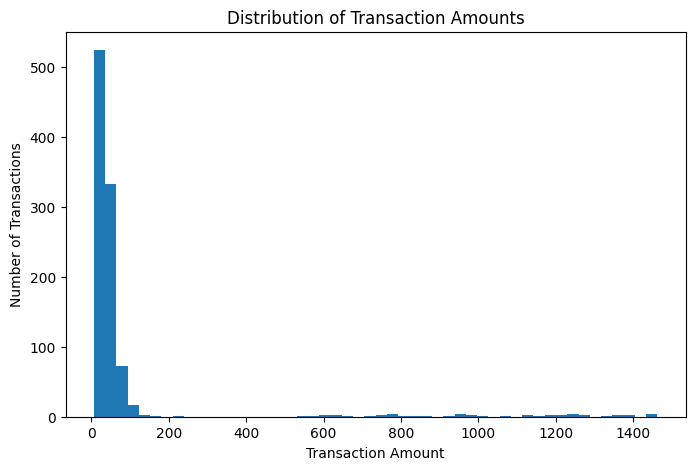

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    transaction_data["transaction_amount"],
    bins=50
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

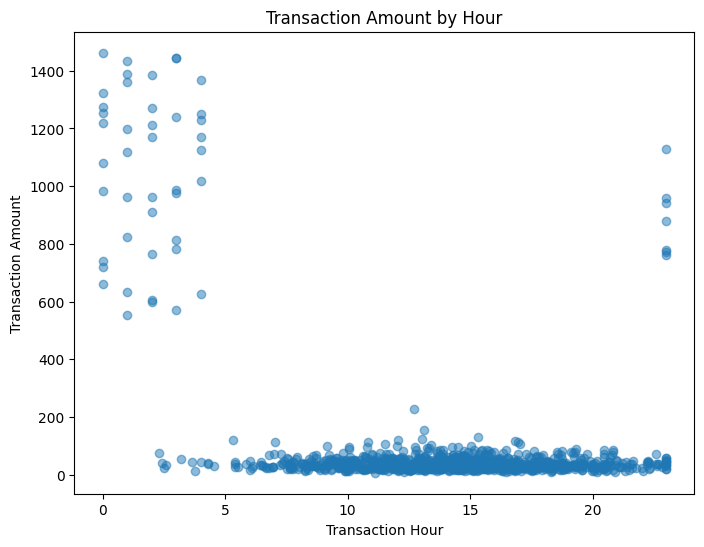

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    transaction_data["transaction_hour"],
    transaction_data["transaction_amount"],
    alpha=0.5
)

plt.title("Transaction Amount by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Transaction Amount")

plt.show()

## 3. Data Preparation

Isolation Forest will use three numerical features:

- `transaction_amount`
- `transaction_hour`
- `daily_transaction_count`

The transaction ID is excluded because it is only an identifier.

The `true_anomaly` variable is also excluded because it represents the known simulated answer and is used only for evaluation.

The numerical features are standardized before anomaly detection so that their scales are comparable.

In [9]:
features = [
    "transaction_amount",
    "transaction_hour",
    "daily_transaction_count"
]

X = transaction_data[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X.shape)
print("Scaled matrix shape:", X_scaled.shape)

Feature matrix shape: (1000, 3)
Scaled matrix shape: (1000, 3)


## 4. Isolation Forest Anomaly Detection

Isolation Forest is an unsupervised anomaly detection algorithm.

Instead of learning a traditional decision boundary, it repeatedly partitions observations using randomly selected features and split values.

Unusual observations generally require fewer partitions to become isolated from the rest of the data.

The `contamination` parameter represents the expected approximate proportion of anomalies.

Because 50 of the 1,000 simulated transactions are unusual, the experiment uses a contamination value of 0.05.

In [10]:
isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

predictions = isolation_forest.fit_predict(
    X_scaled
)

# Isolation Forest:
#  1 = normal
# -1 = anomaly

transaction_data["predicted_anomaly"] = np.where(
    predictions == -1,
    1,
    0
)

print(
    "Detected anomalies:",
    transaction_data["predicted_anomaly"].sum()
)

Detected anomalies: 50


In [11]:
transaction_data["anomaly_score"] = (
    -isolation_forest.score_samples(
        X_scaled
    )
)

transaction_data[
    [
        "transaction_id",
        "transaction_amount",
        "transaction_hour",
        "daily_transaction_count",
        "predicted_anomaly",
        "anomaly_score"
    ]
].sort_values(
    "anomaly_score",
    ascending=False
).head(10)

,transaction_id,transaction_amount,transaction_hour,daily_transaction_count,predicted_anomaly,anomaly_score
754,755,943.039977,23.0,29,1,0.781177
941,942,762.416082,23.0,27,1,0.764445
27,28,1129.219193,23.0,15,1,0.763412
251,252,958.253315,23.0,15,1,0.761348
899,900,878.347582,23.0,23,1,0.760833
117,118,770.348590,23.0,24,1,0.754171
639,640,778.143640,23.0,21,1,0.745895
786,787,1445.122449,3.0,16,1,0.728880
569,570,1274.672937,0.0,15,1,0.723577
872,873,1462.365316,0.0,26,1,0.721621


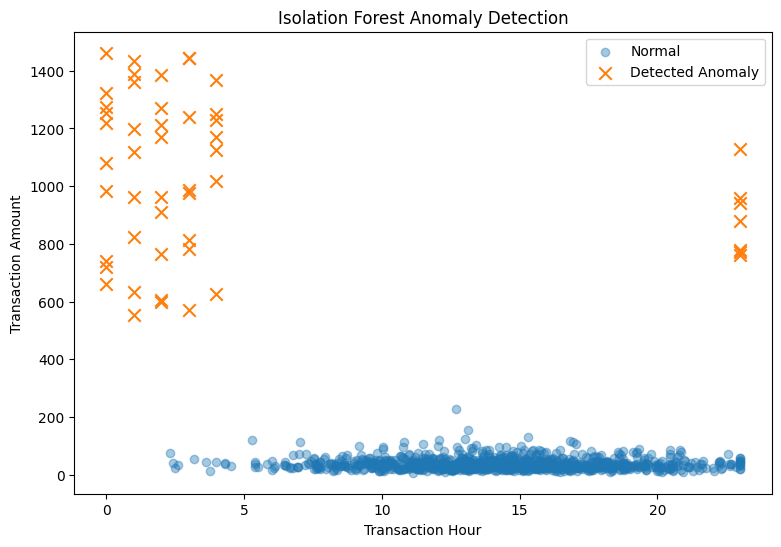

In [12]:
normal = transaction_data[
    transaction_data["predicted_anomaly"] == 0
]

detected_anomalies = transaction_data[
    transaction_data["predicted_anomaly"] == 1
]

plt.figure(figsize=(9, 6))

plt.scatter(
    normal["transaction_hour"],
    normal["transaction_amount"],
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    detected_anomalies["transaction_hour"],
    detected_anomalies["transaction_amount"],
    marker="x",
    s=80,
    label="Detected Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Transaction Hour")
plt.ylabel("Transaction Amount")

plt.legend()

plt.show()

## 5. Evaluation

Isolation Forest is an unsupervised model and did not receive the `true_anomaly` labels during training.

Because the dataset was generated in a controlled environment, the detected anomalies can now be compared with the known simulated anomalies.

This provides a simple way to evaluate how effectively the unsupervised model recovered the intentionally unusual transactions.

In [13]:
cm = confusion_matrix(
    transaction_data["true_anomaly"],
    transaction_data["predicted_anomaly"]
)

print("Confusion Matrix")
print("----------------")
print(cm)

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        transaction_data["true_anomaly"],
        transaction_data["predicted_anomaly"],
        target_names=[
            "Normal",
            "Anomaly"
        ]
    )
)

Confusion Matrix
----------------
[[950   0]
 [  0  50]]

Classification Report
---------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       950
     Anomaly       1.00      1.00      1.00        50

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



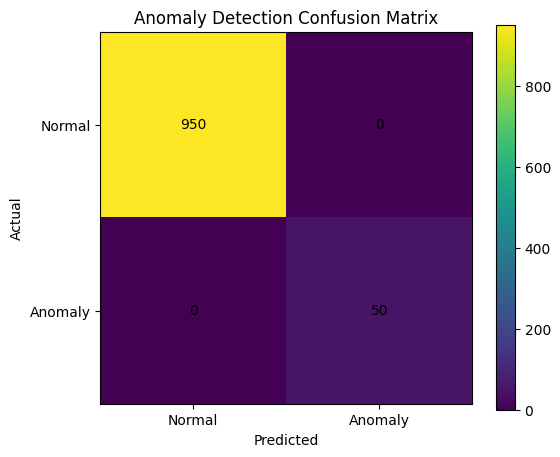

In [14]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Anomaly Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Normal", "Anomaly"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Anomaly"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

### Evaluation Results

Isolation Forest detected 50 transactions as anomalies, which matches the 50 known simulated anomalies in the dataset.

The confusion matrix was:

- True Normal: 950
- False Positive: 0
- False Negative: 0
- True Anomaly: 50

For the anomaly class, the model achieved:

- **Precision: 1.00**
- **Recall: 1.00**
- **F1-score: 1.00**

In this controlled experiment, Isolation Forest successfully separated all intentionally generated anomalous transactions from the normal transactions.

However, this perfect performance should not be interpreted as evidence that Isolation Forest would achieve perfect fraud detection in a real financial system. The simulated anomalies were intentionally generated with characteristics that differ substantially from normal transactions, and the contamination parameter was set to the known simulated anomaly rate of 5%.

Real-world transaction behavior is considerably more complex and usually contains overlapping patterns, unknown anomaly rates, and ambiguous cases.

## 6. Anomaly Interpretation

The transactions with the highest anomaly scores show combinations of characteristics that differ substantially from normal transaction behavior.

Several of the most anomalous observations have:

- Transaction amounts above several hundred dollars
- Transactions occurring around midnight or early morning
- Very high daily transaction counts

For example, some highly ranked anomalies occurred at 11 PM with more than 20 transactions during the day, while other transactions exceeded $1,000 and occurred between midnight and 3 AM.

Isolation Forest considers the combination of multiple features rather than relying on a single fixed threshold.

This illustrates an important advantage of multivariate anomaly detection: a transaction may become suspicious because of the combination of amount, timing, and behavioral frequency rather than because one variable alone is unusual.

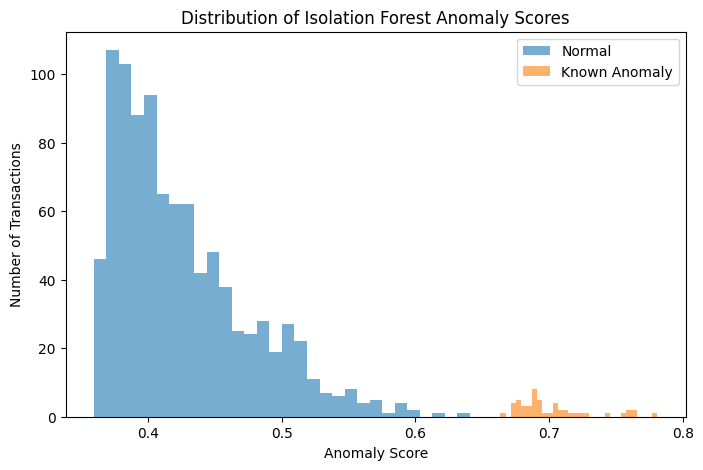

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    transaction_data[
        transaction_data["true_anomaly"] == 0
    ]["anomaly_score"],
    bins=30,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    transaction_data[
        transaction_data["true_anomaly"] == 1
    ]["anomaly_score"],
    bins=30,
    alpha=0.6,
    label="Known Anomaly"
)

plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Transactions")

plt.legend()

plt.show()

## 7. Business Applications and Recommendations

An anomaly detection system like this could be used as an initial transaction screening mechanism.

### Risk-Based Transaction Review

Transactions with high anomaly scores could be prioritized for additional review instead of manually inspecting every transaction.

### Multi-Factor Monitoring

The experiment demonstrates that unusual behavior can result from combinations of transaction amount, time, and frequency.

A production monitoring system should therefore consider multiple behavioral signals rather than relying only on a fixed transaction amount threshold.

### Human Review

A detected anomaly should not automatically be classified as fraud.

Legitimate customers can also perform unusual transactions. High-risk transactions could instead be sent to a fraud analyst or an additional verification process.

### Continuous Monitoring

Customer behavior and fraud patterns can change over time. A deployed anomaly detection system should therefore be monitored and periodically reevaluated using newer transaction data.

## 8. Limitations

This experiment uses synthetic transaction data and intentionally creates anomalies that are substantially different from normal transactions.

The contamination parameter was also set to 0.05 because the simulated dataset was known to contain 5% anomalies.

These controlled conditions help demonstrate how Isolation Forest works, but they make the experiment easier than real-world anomaly detection.

In a real financial dataset:

- The true anomaly rate may be unknown.
- Fraudulent and legitimate transactions may have overlapping characteristics.
- Some anomalies may represent legitimate unusual behavior.
- Fraud patterns may change over time.
- False positives can create operational costs and inconvenience customers.

Therefore, the perfect classification results obtained in this experiment should be interpreted as validation of the controlled simulation rather than expected real-world performance.

Anomaly detection identifies unusual behavior; it does not by itself prove fraudulent activity.

## 9. Experiment Conclusion

This experiment replicated and adapted the instructor's anomaly detection project using Isolation Forest.

The workflow included:

- Synthetic financial transaction generation
- Exploratory data analysis
- Feature standardization
- Isolation Forest anomaly detection
- Anomaly score analysis
- Visualization of detected anomalies
- Evaluation against known simulated anomalies
- Business interpretation
- Limitations and deployment considerations

The dataset contained **1,000 transactions**, including **50 intentionally simulated anomalies**.

Isolation Forest detected 50 anomalies and correctly recovered all 50 simulated anomalous transactions in this controlled experiment.

The strongest anomalies generally combined unusually high transaction amounts, unusual transaction times, and high daily transaction frequency.

The perfect evaluation results reflect the deliberately well-separated synthetic data and known anomaly proportion rather than expected real-world fraud detection performance.

Overall, the experiment demonstrates how unsupervised anomaly detection can identify unusual multidimensional behavior and support risk-based transaction monitoring.